<a href="https://colab.research.google.com/github/KP-365/Skinrash-detection/blob/main/Eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/KP-365/Skinrash-detection.git

Cloning into 'Skinrash-detection'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 80 (delta 40), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 64.75 MiB | 14.49 MiB/s, done.
Resolving deltas: 100% (40/40), done.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from datasets import load_dataset
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

REPO_DIR = "Skinrash-detection"
CHECKPOINT_FILE = "models/trained_models/best_model_tuned_final.pt"   # adjust if you pushed it under a different name
NUM_CLASSES = 8
IMG_SIZE = 224
DROPOUT_P = 0.3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cpu


In [3]:
clean = load_dataset("eceunal/bug-bite-images-hf")
test_split = clean["test"]
labels = clean["train"].features["label"].names
print(f"Test set size: {len(test_split)}")
print(f"Classes: {labels}")

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class BugBiteDataset(Dataset):
    def __init__(self, hf_split, transform):
        self.data = hf_split
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        ex = self.data[idx]
        img = ex["image"].convert("RGB")
        return self.transform(img), ex["label"]

test_loader = DataLoader(BugBiteDataset(test_split, eval_transform), batch_size=32, shuffle=False)

README.md:   0%|          | 0.00/764 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 17.5MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  918kB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/896 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/106 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/53 [00:00<?, ? examples/s]

Test set size: 53
Classes: ['ants', 'bed_bugs', 'chiggers', 'fleas', 'mosquitos', 'no_bites', 'spiders', 'ticks']


In [4]:
def build_model():
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=DROPOUT_P),
        nn.Linear(in_features, NUM_CLASSES)
    )
    return model.to(DEVICE)

model = build_model()
checkpoint_path = os.path.join(REPO_DIR, CHECKPOINT_FILE)
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE, weights_only=False))
print(f"Loaded checkpoint: {checkpoint_path}")

Loaded checkpoint: Skinrash-detection/models/trained_models/best_model_tuned_final.pt


In [5]:
def enable_mc_dropout(model):
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()

def mc_dropout_predict(model, loader, n_samples=30):
    model.eval()
    enable_mc_dropout(model)
    all_mean_probs, all_std_probs, all_preds, all_targets = [], [], [], []
    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(DEVICE)
            batch_probs = torch.zeros(n_samples, imgs.size(0), NUM_CLASSES).to(DEVICE)
            for i in range(n_samples):
                outputs = model(imgs)
                batch_probs[i] = F.softmax(outputs, dim=1)
            mean_probs = batch_probs.mean(dim=0)
            std_probs = batch_probs.std(dim=0)
            preds = mean_probs.argmax(dim=1)
            all_mean_probs.append(mean_probs.cpu().numpy())
            all_std_probs.append(std_probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.numpy())
    return (np.concatenate(all_mean_probs), np.concatenate(all_std_probs),
            np.array(all_preds), np.array(all_targets))

mean_probs, std_probs, preds, targets = mc_dropout_predict(model, test_loader, n_samples=30)
acc = np.mean(preds == targets)
print(f"Test accuracy: {acc:.4f}")

Test accuracy: 0.7547


Mean entropy (correct):   0.6832
Mean entropy (incorrect): 0.8610


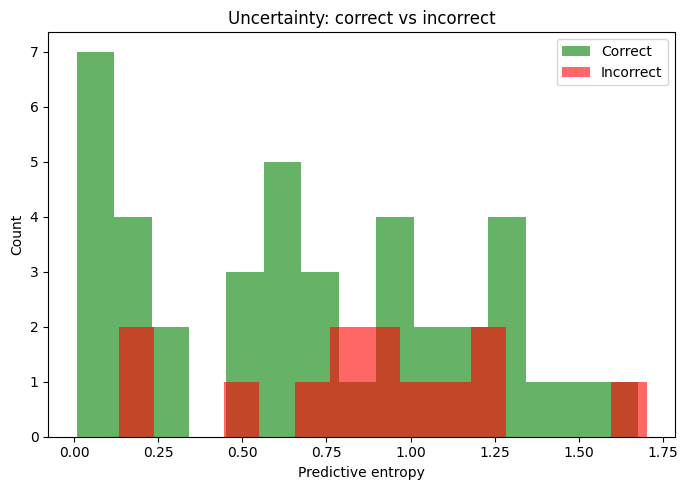

In [6]:
def predictive_entropy(probs):
    eps = 1e-10
    return -np.sum(probs * np.log(probs + eps), axis=1)

entropies = predictive_entropy(mean_probs)
confidences = mean_probs.max(axis=1)
correct_mask = preds == targets

print(f"Mean entropy (correct):   {entropies[correct_mask].mean():.4f}")
print(f"Mean entropy (incorrect): {entropies[~correct_mask].mean():.4f}")

fig, ax = plt.subplots(figsize=(7,5))
ax.hist(entropies[correct_mask], bins=15, alpha=0.6, label="Correct", color="green")
ax.hist(entropies[~correct_mask], bins=15, alpha=0.6, label="Incorrect", color="red")
ax.set_xlabel("Predictive entropy")
ax.set_ylabel("Count")
ax.set_title("Uncertainty: correct vs incorrect")
ax.legend()
plt.tight_layout()
plt.savefig("entropy_distribution.png", dpi=150)
plt.show()

Expected Calibration Error (ECE): 0.0988


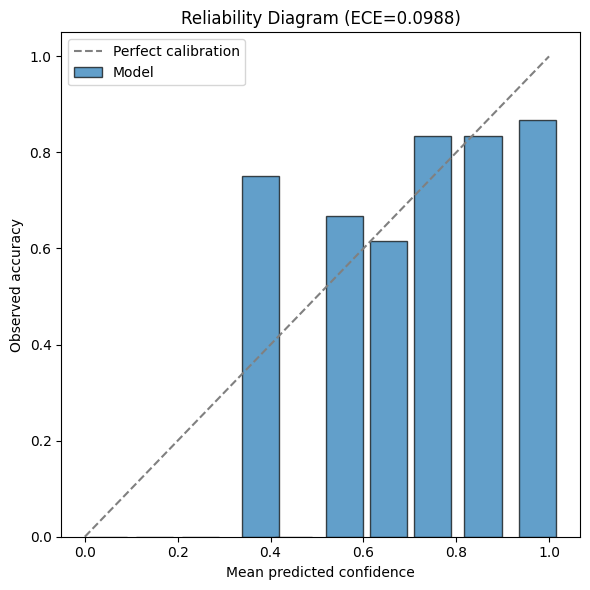

In [7]:
def reliability_diagram(confidences, correct_mask, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins+1)
    bin_accs, bin_confs, bin_counts = [], [], []
    for i in range(n_bins):
        mask = (confidences >= bin_edges[i]) & (confidences < bin_edges[i+1])
        if mask.sum() > 0:
            bin_accs.append(correct_mask[mask].mean())
            bin_confs.append(confidences[mask].mean())
            bin_counts.append(mask.sum())
        else:
            bin_accs.append(0)
            bin_confs.append((bin_edges[i]+bin_edges[i+1])/2)
            bin_counts.append(0)
    return np.array(bin_confs), np.array(bin_accs), np.array(bin_counts)

bin_confs, bin_accs, bin_counts = reliability_diagram(confidences, correct_mask)
ece = np.sum(bin_counts / bin_counts.sum() * np.abs(bin_accs - bin_confs))
print(f"Expected Calibration Error (ECE): {ece:.4f}")

fig, ax = plt.subplots(figsize=(6,6))
ax.plot([0,1], [0,1], linestyle="--", color="gray", label="Perfect calibration")
ax.bar(bin_confs, bin_accs, width=0.08, alpha=0.7, edgecolor="black", label="Model")
ax.set_xlabel("Mean predicted confidence")
ax.set_ylabel("Observed accuracy")
ax.set_title(f"Reliability Diagram (ECE={ece:.4f})")
ax.legend()
plt.tight_layout()
plt.savefig("reliability_diagram.png", dpi=150)
plt.show()

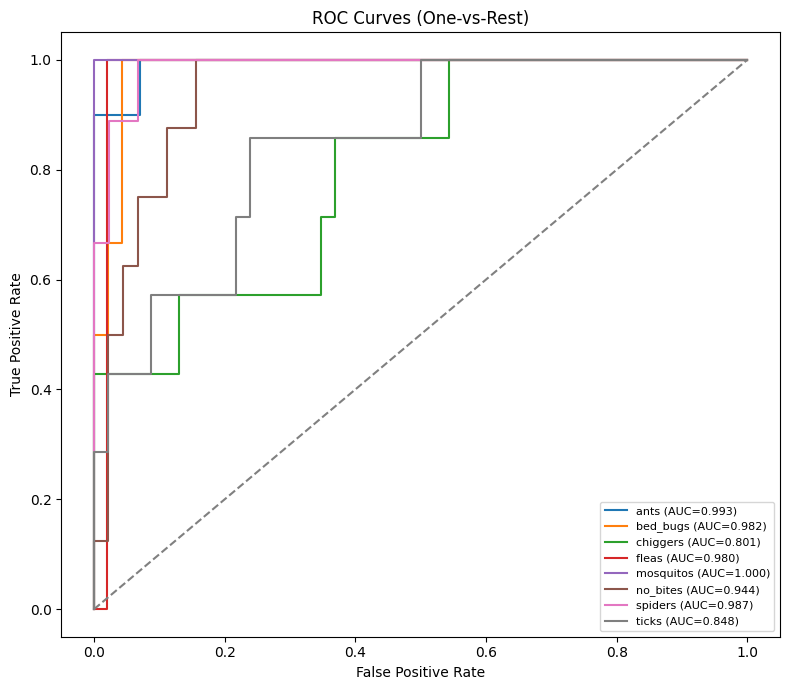


Per-class AUC:
  ants: 0.9930
  bed_bugs: 0.9823
  chiggers: 0.8012
  fleas: 0.9804
  mosquitos: 1.0000
  no_bites: 0.9444
  spiders: 0.9874
  ticks: 0.8478

Mean AUC: 0.9421


In [8]:
y_true_bin = label_binarize(targets, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(8,7))
auc_scores = {}

for i, class_name in enumerate(labels):
    if y_true_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], mean_probs[:, i])
    auc = roc_auc_score(y_true_bin[:, i], mean_probs[:, i])
    auc_scores[class_name] = auc
    ax.plot(fpr, tpr, label=f"{class_name} (AUC={auc:.3f})")

ax.plot([0,1], [0,1], linestyle="--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves (One-vs-Rest)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

print("\nPer-class AUC:")
for name, score in auc_scores.items():
    print(f"  {name}: {score:.4f}")
print(f"\nMean AUC: {np.mean(list(auc_scores.values())):.4f}")

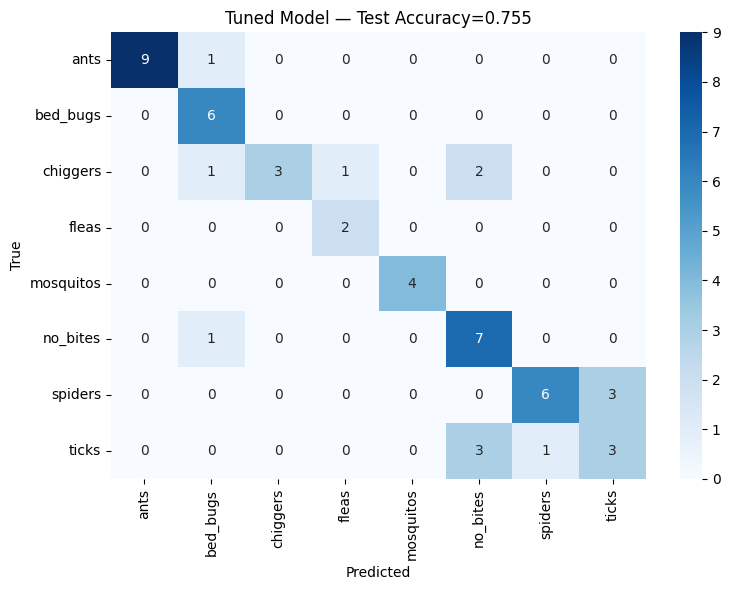


Classification report:
              precision    recall  f1-score   support

        ants       1.00      0.90      0.95        10
    bed_bugs       0.67      1.00      0.80         6
    chiggers       1.00      0.43      0.60         7
       fleas       0.67      1.00      0.80         2
   mosquitos       1.00      1.00      1.00         4
    no_bites       0.58      0.88      0.70         8
     spiders       0.86      0.67      0.75         9
       ticks       0.50      0.43      0.46         7

    accuracy                           0.75        53
   macro avg       0.78      0.79      0.76        53
weighted avg       0.80      0.75      0.75        53



In [9]:
cm = confusion_matrix(targets, preds, labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.title(f'Tuned Model — Test Accuracy={acc:.3f}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('tuned_model_confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification report:")
print(classification_report(targets, preds, target_names=labels, zero_division=0))